In [1]:
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from tqdm.auto import tqdm
from pathlib import Path


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Malaria-Cell-Classification"
)

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

In [4]:
#import project modules
from src import (
    MalariaDataPreprocessor,
    MalariaCNN,
    MalariaTrainer,
    set_seed,
    get_device,
    count_parameters,
)

In [5]:
#reproducibility
set_seed(42)

device = get_device()

Using GPU : Tesla T4


In [6]:
# ============================================================
# Training Configuration
# ============================================================

TRAIN_CONFIG = {

    # --------------------------------------------------------
    # Project
    # --------------------------------------------------------

    "project_dir": PROJECT_DIR,

    "dataset_dir": PROJECT_DIR / "dataset",

    "artifacts_dir": PROJECT_DIR / "artifacts",

    "checkpoints_dir": PROJECT_DIR / "checkpoints",

    "outputs_dir": PROJECT_DIR / "outputs",

    # --------------------------------------------------------
    # Experiment
    # --------------------------------------------------------

    "experiment_name": "baseline_cnn",

    "random_seed": 42,

    "device": device,

    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------

    "image_size": (128, 128),

    "batch_size": 32,

    "validation_split": 0.15,

    "test_split": 0.15,

    "num_workers": 0,

    "pin_memory": True,

    # --------------------------------------------------------
    # Data Augmentation
    # --------------------------------------------------------

    "rotation_degrees": 15,

    "horizontal_flip_prob": 0.5,

    "vertical_flip_prob": 0.5,

    "brightness": 0.10,

    "contrast": 0.10,

    "saturation": 0.10,

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    "input_channels": 3,

    "num_classes": 2,

    "conv_channels": [32, 64, 128],

    "kernel_size": 3,

    "dropout": 0.30,

    "activation": "relu",

    "use_batchnorm": True,

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    "epochs": 20,

    "learning_rate": 1e-3,

    "weight_decay": 1e-4,

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # --------------------------------------------------------

    "scheduler": "ReduceLROnPlateau",

    "scheduler_factor": 0.1,

    "scheduler_patience": 3,

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    "save_best_only": True,

    "checkpoint_name": "best_model.pt",
}

In [7]:
# ============================================================
# Build Preprocessing Pipeline
# ============================================================

preprocessor = MalariaDataPreprocessor(
    project_dir=TRAIN_CONFIG["project_dir"],
    image_size=TRAIN_CONFIG["image_size"],
    batch_size=TRAIN_CONFIG["batch_size"],
    validation_split=TRAIN_CONFIG["validation_split"],
    test_split=TRAIN_CONFIG["test_split"],
    random_state=TRAIN_CONFIG["random_seed"],
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=TRAIN_CONFIG["pin_memory"],
    rotation_degrees=TRAIN_CONFIG["rotation_degrees"],
    horizontal_flip_prob=TRAIN_CONFIG["horizontal_flip_prob"],
    vertical_flip_prob=TRAIN_CONFIG["vertical_flip_prob"],
    brightness=TRAIN_CONFIG["brightness"],
    contrast=TRAIN_CONFIG["contrast"],
    saturation=TRAIN_CONFIG["saturation"],
)

preprocessor.prepare()

Dataset already extracted.

Dataset validation successful.
Dataset Location : /content/drive/MyDrive/Malaria-Cell-Classification/dataset/extracted/cell_images
Classes Found    : ['Parasitized', 'Uninfected']
Dataset Metadata
Total Images : 27558

   image_id                                           filepath  \
0         0  /content/drive/MyDrive/Malaria-Cell-Classifica...   
1         1  /content/drive/MyDrive/Malaria-Cell-Classifica...   
2         2  /content/drive/MyDrive/Malaria-Cell-Classifica...   
3         3  /content/drive/MyDrive/Malaria-Cell-Classifica...   
4         4  /content/drive/MyDrive/Malaria-Cell-Classifica...   

                                        filename   class_name  label  width  \
0  C100P61ThinF_IMG_20150918_144104_cell_162.png  Parasitized      1    142   
1  C100P61ThinF_IMG_20150918_144104_cell_163.png  Parasitized      1    148   
2  C100P61ThinF_IMG_20150918_144104_cell_164.png  Parasitized      1    139   
3  C100P61ThinF_IMG_20150918_144104_cell

In [8]:
# ============================================================
# Build CNN Model
# ============================================================

model = MalariaCNN(
    input_channels=TRAIN_CONFIG["input_channels"],
    num_classes=TRAIN_CONFIG["num_classes"],
    conv_channels=TRAIN_CONFIG["conv_channels"],
    kernel_size=TRAIN_CONFIG["kernel_size"],
    dropout=TRAIN_CONFIG["dropout"],
    activation=TRAIN_CONFIG["activation"],
    use_batchnorm=TRAIN_CONFIG["use_batchnorm"],
)

model = model.to(TRAIN_CONFIG["device"])

In [9]:
# ============================================================
# Model Summary
# ============================================================

print(model)

print("\nTrainable Parameters:",
      f"{count_parameters(model):,}")

MalariaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): D

In [10]:
# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss()

print("Loss Function")
print("-" * 30)
print(criterion)

Loss Function
------------------------------
CrossEntropyLoss()


In [11]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=TRAIN_CONFIG["learning_rate"],

    weight_decay=TRAIN_CONFIG["weight_decay"],
)

print("Optimizer")
print("-" * 30)
print(optimizer)

Optimizer
------------------------------
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [12]:
# ============================================================
# Learning Rate Scheduler
# ============================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=TRAIN_CONFIG["scheduler_factor"],

    patience=TRAIN_CONFIG["scheduler_patience"],
)

print("Scheduler")
print("-" * 30)
print(scheduler)

Scheduler
------------------------------


In [15]:
# ============================================================
# Initialize Trainer
# ============================================================

trainer = MalariaTrainer(
    model=model,
    train_loader=preprocessor.train_loader,
    val_loader=preprocessor.val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=TRAIN_CONFIG["device"],
    epochs=TRAIN_CONFIG["epochs"],
    checkpoint_path=TRAIN_CONFIG["checkpoints_dir"] / "best_model.pth",
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


In [16]:
# ============================================================
# Train Model
# ============================================================

trainer.fit()

print("\nTraining completed successfully.")


Epoch 1/20
------------------------------------------------------------


Training:   0%|          | 0/603 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

✓ Best model saved.
Train Loss: 0.6418 | Val Loss: 0.5996
Train Accuracy: 0.6503 | Val Accuracy: 0.6456
Train F1: 0.6228 | Val F1: 0.5170

Epoch 2/20
------------------------------------------------------------


Training:   0%|          | 0/603 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

✓ Best model saved.
Train Loss: 0.1824 | Val Loss: 0.1513
Train Accuracy: 0.9440 | Val Accuracy: 0.9461
Train F1: 0.9423 | Val F1: 0.9446

Epoch 20/20
------------------------------------------------------------


Training:   0%|          | 0/603 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

✓ Best model saved.
Train Loss: 0.1829 | Val Loss: 0.1500
Train Accuracy: 0.9412 | Val Accuracy: 0.9490
Train F1: 0.9394 | Val F1: 0.9476

Training completed successfully.


In [17]:
# ============================================================
# Retrieve Training History
# ============================================================

history = trainer.tracker.get_history()

history_df = trainer.tracker.to_dataframe()

print(f"Epochs Completed : {len(trainer.tracker)}")
print(f"Metrics Recorded : {len(history)}")

Epochs Completed : 20
Metrics Recorded : 10


In [18]:
# ============================================================
# Training History
# ============================================================

history_df

,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1
0,0.641812,0.599633,0.650285,0.645622,0.675932,0.811594,0.577398,0.379294,0.622791,0.516980
1,0.532336,0.402396,0.771280,0.860910,0.814445,0.962206,0.702644,0.751330,0.754425,0.843792
2,0.357182,0.242781,0.881389,0.928157,0.924818,0.965789,0.830275,0.887760,0.875000,0.925132
3,0.279258,0.219280,0.913478,0.928641,0.952565,0.977371,0.870295,0.877600,0.909574,0.924802
4,0.243647,0.188102,0.922654,0.942429,0.960674,0.967297,0.881389,0.915820,0.919325,0.940855
5,0.228747,0.178888,0.928875,0.944364,0.963162,0.966480,0.891861,0.920658,0.926141,0.943013
6,0.220487,0.181321,0.933852,0.939284,0.966864,0.972917,0.898497,0.903725,0.931427,0.937045
7,0.211123,0.172144,0.934785,0.947750,0.968495,0.968608,0.898808,0.925496,0.932351,0.946561
8,0.210129,0.172657,0.934007,0.946541,0.966771,0.973819,0.898911,0.917755,0.931607,0.944956
9,0.201738,0.167218,0.937325,0.949686,0.968771,0.968734,0.903784,0.929366,0.935150,0.948642


In [19]:
# ============================================================
# Save Training History
# ============================================================

history_path = (
    TRAIN_CONFIG["outputs_dir"] /
    "training_history.csv"
)

trainer.tracker.save(history_path)

print(f"Training history saved to:\n{history_path}")

Training history saved to:
/content/drive/MyDrive/Malaria-Cell-Classification/outputs/training_history.csv


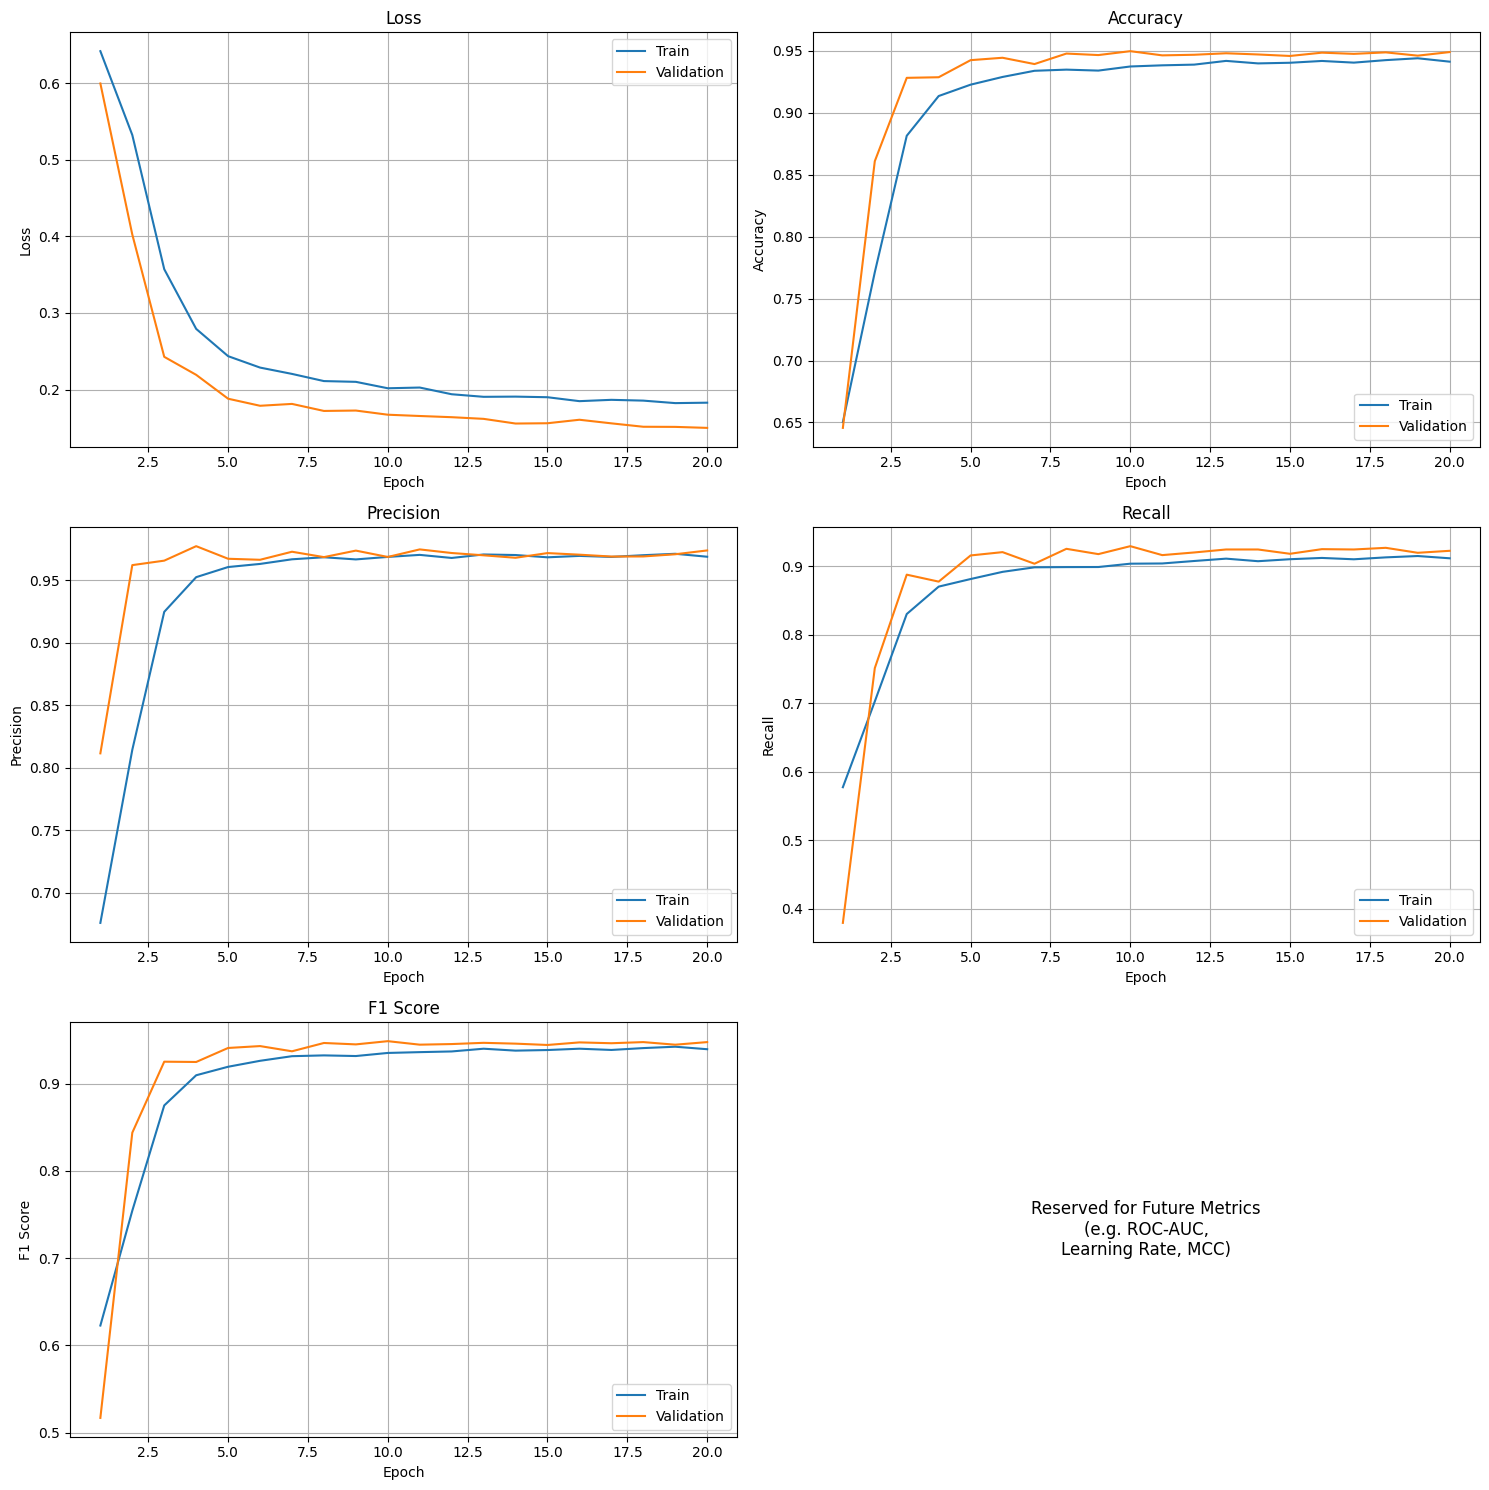

In [20]:
trainer.plot_history()

### **Training Summary** ###
In this notebook, the convolutional neural network was successfully trained using the preprocessing pipeline developed in the previous stage. The training process included data augmentation, validation after each epoch, learning rate scheduling, checkpointing, metric tracking, and early stopping to reduce the risk of overfitting.

Throughout training, the model's performance was monitored using loss, accuracy, precision, recall, and F1 score on both the training and validation datasets. The best-performing model was automatically saved based on the lowest validation loss, while the complete training history was recorded for future analysis and comparison.

The resulting checkpoint and training metrics provide the foundation for the next phase of the project, where the model will be evaluated on the unseen test dataset to assess its generalization performance and produce detailed evaluation metrics, including the confusion matrix, ROC curve, and classification report.